In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.ensemble import StackingClassifier

## Preprocessing
[Titanic dataset](https://www.kaggle.com/competitions/titanic/overview)

In [17]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df = [df_train, df_test]

In [7]:
df_train.info()
print("-" * 40)
df_test.info()
print("-" * 40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passenger

In [10]:
print(df_train.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [11]:
print(df_test.describe())

       PassengerId      Pclass         Age       SibSp       Parch        Fare
count   418.000000  418.000000  332.000000  418.000000  418.000000  417.000000
mean   1100.500000    2.265550   30.272590    0.447368    0.392344   35.627188
std     120.810458    0.841838   14.181209    0.896760    0.981429   55.907576
min     892.000000    1.000000    0.170000    0.000000    0.000000    0.000000
25%     996.250000    1.000000   21.000000    0.000000    0.000000    7.895800
50%    1100.500000    3.000000   27.000000    0.000000    0.000000   14.454200
75%    1204.750000    3.000000   39.000000    1.000000    0.000000   31.500000
max    1309.000000    3.000000   76.000000    8.000000    9.000000  512.329200


In [19]:
for dataset in df:
  dataset['Age'] = dataset['Age'].fillna(dataset['Age'].median())
  dataset['Fare'] = dataset['Fare'].fillna(dataset['Fare'].median())
  dataset['Embarked'] = dataset['Embarked'].fillna(dataset['Embarked'].mode()[0])

drop_column = ["PassengerId", "Name", "Ticket", "Cabin"]
df_test.drop(drop_column[1:], axis=1, inplace=True)
df_train.drop(drop_column, axis=1, inplace=True)

print(df_test.isnull().sum())
print("-" * 40)
print(df_train.isnull().sum())

PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64
----------------------------------------
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for dataset in df:
  dataset['Sex'] = le.fit_transform(dataset['Sex'])
  dataset['Embarked'] = le.fit_transform(dataset['Embarked'])

In [24]:
for dataset in df:
  dataset["FamilySize"] = dataset["SibSp"] + dataset["Parch"] + 1
  dataset["IsAlone"]= [1 if size > 1 else 0 for size in dataset["FamilySize"]]
drop_column = ["SibSp", "Parch"]
df_test.drop(drop_column, axis=1, inplace=True)
df_train.drop(drop_column, axis=1, inplace=True)

In [25]:
df_train.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone
0,0,3,1,22.0,7.2500,2,2,1
1,1,1,0,38.0,71.2833,0,2,1
2,1,3,0,26.0,7.9250,2,1,0
3,1,1,0,35.0,53.1000,2,2,1
4,0,3,1,35.0,8.0500,2,1,0


In [ ]:
for dataset in df:
  dataset["Age"] = dataset["Age"].pd.cut(dataset['Age'], bins=[0, 10, 20, 30, 40, 60, 80], labels=False)
  dataset["Fare"] = pd.qcut(dataset['Fare'], q=4, labels=False)

## EDA
###1. Survival Rates by Passenger Class
*   1st Class: 63% survival rate
*   2nd Class: 47% survival rate
*   3rd Class: 24% survival rate

-Key Takeaway: Wealthier passengers (higher classes) had a significantly higher chance of survival, likely due to better access to lifeboats and proximity to the deck.
###2. Survival Rates by Gender
*Females: 68% survival rate
*Males: 32% survival rate

-Key Takeaway: Females had a much higher survival rate than males, reflecting the "women and children first" protocol during the evacuation.
###3. Impact of Family Structure on Survival
####Females
*Alone ~80%

*Not alone ~70%
####Males
*Alone ~15%

*Not alone ~30%

-Key Takeaway: Family dynamics played a role in survival. For females, larger family groups (siblings and parents/children) reduced survival chances, possibly due to challenges in evacuation. For males, having parents/children (but not siblings) improved survival, perhaps indicating they were prioritized as part of family units.

###4. Survival Rates by Age Group
*  0-20 and 20-30 Age Groups: Highest survival rates, likely due to prioritization of younger passengers.
*30-40 Age Group: Still relatively high survival rates, but slightly lower than younger groups.
*After Age 40: Sharp drop in survival rates, suggesting older passengers were less likely to survive.

-Key Takeaway: Younger passengers had a better chance of survival, possibly due to physical ability to evacuate or prioritization during rescue efforts.

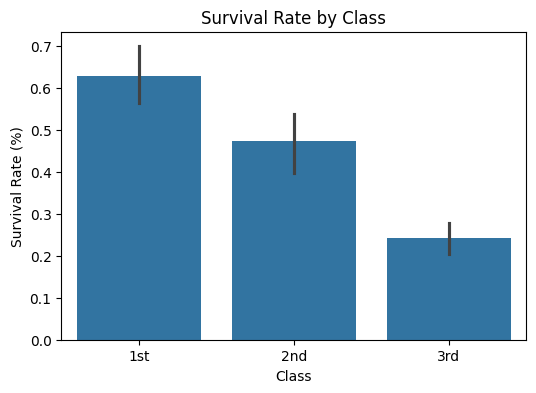

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [28]:
survivors_by_class = df_train.groupby("Pclass")["Survived"].sum()
amount_by_class = df_train.groupby("Pclass")["Survived"].count()
survivors_by_class_percentage = (survivors_by_class / amount_by_class) * 100

survival_df = survivors_by_class_percentage.reset_index()
survival_df.columns = ['Pclass', 'Survival Rate (%)']

plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=df_train)
plt.title('Survival Rate by Class')
plt.xlabel('Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(ticks=[0, 1, 2], labels=['1st', '2nd', '3rd'])

plt.show()
print(survivors_by_class_percentage)

In [29]:
survivors_by_gender = df_train.groupby("Sex")["Survived"].sum() / df_train["Survived"].sum() * 100
print(survivors_by_gender)

Sex
0    68.128655
1    31.871345
Name: Survived, dtype: float64


<Axes: xlabel='Sex'>

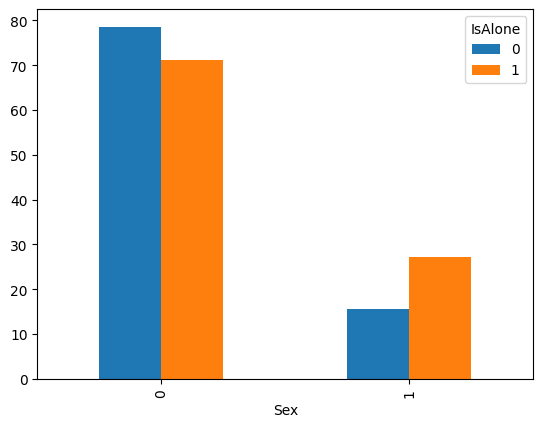

In [32]:
survivors_and_siblings = pd.crosstab(df_train["Sex"],
                                     df_train["IsAlone"],
                                     values = df_train["Survived"], aggfunc="sum"
                                     )

total_individuals = pd.crosstab(
    df_train["Sex"],
    df_train["IsAlone"]
    )

survivors_and_siblings_percentage = (survivors_and_siblings / total_individuals) * 100

survivors_and_siblings_percentage.plot.bar()

## Training model

XGBClassifier Best Parameters: {'gamma': 0.2, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 60}

XGBClassifier Best Score: 0.8406440273680247

RandomForestClassifier Best Parameters: {'max_depth': 5, 'n_estimators': 50}

RandomForestClassifier Best Score: 0.8260372857949909

In [45]:
from sklearn.linear_model import LogisticRegression
estimators = [
    ('xgb', XGBClassifier(**{'gamma': 0.2, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 60})),
    ('rf', RandomForestClassifier(**{'max_depth': 5, 'n_estimators': 50}))
]
model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv = 5, passthrough=True)
model.fit(df_train.drop("Survived", axis=1), df_train["Survived"])

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


StackingClassifier(cv=5,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None, gamma=0.2,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learn...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=5,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=60, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=None, ...)),
                               ('rf',
                                RandomForestClassifier(max_depth=5,
                                                       n_estimators=50))],
                   final_estimator=LogisticRegression(), passthrough=True)

In [46]:
model.score(df_train.drop("Survived", axis=1), df_train["Survived"])

0.8731762065095399

In [47]:
y = model.predict(df_test.drop("PassengerId", axis=1))
submission = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": y
})
submission.to_csv('submission.csv', index=False)

#Result
77,27% on kaggle